# Nama  : Kevin Rafael Owen
# NIM   : 4222301038
# Kelas : RE B PAGI

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings("ignore")

# Pengaturan tampilan
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

## 2. Load Dataset

In [2]:
df = pd.read_csv("WineQT.csv")

print(f"Shape dataset: {df.shape}")
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
df.head(10)

Shape dataset: (1143, 13)
Jumlah baris   : 1143
Jumlah kolom   : 13


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


## 3. Eksplorasi Data (EDA)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000
mean,8.311,0.531,0.268,2.532,0.087,15.615,45.915,0.997,3.311,0.658,10.442,5.657,804.969
std,1.748,0.180,0.197,1.356,0.047,10.250,32.782,0.002,0.157,0.170,1.082,0.806,463.997
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000,0.000
25%,7.100,0.392,0.090,1.900,0.070,7.000,21.000,0.996,3.205,0.550,9.500,5.000,411.000
50%,7.900,0.520,0.250,2.200,0.079,13.000,37.000,0.997,3.310,0.620,10.200,6.000,794.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,61.000,0.998,3.400,0.730,11.100,6.000,1209.500
max,15.900,1.580,1.000,15.500,0.611,68.000,289.000,1.004,4.010,2.000,14.900,8.000,1597.000


In [5]:
print("Missing Values per Kolom:")
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")

Missing Values per Kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
Total missing values: 0


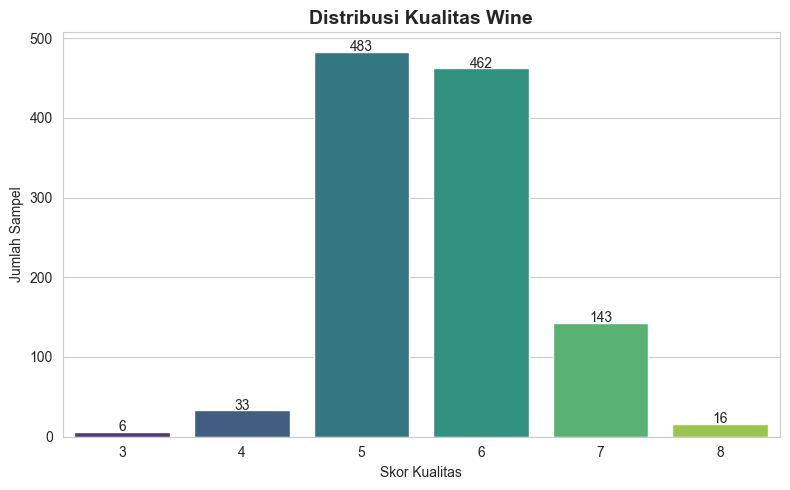

In [6]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribusi Kualitas Wine", fontsize=14, fontweight="bold")
plt.xlabel("Skor Kualitas")
plt.ylabel("Jumlah Sampel")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()+1),
                ha="center", fontsize=10)
plt.tight_layout()
plt.show()

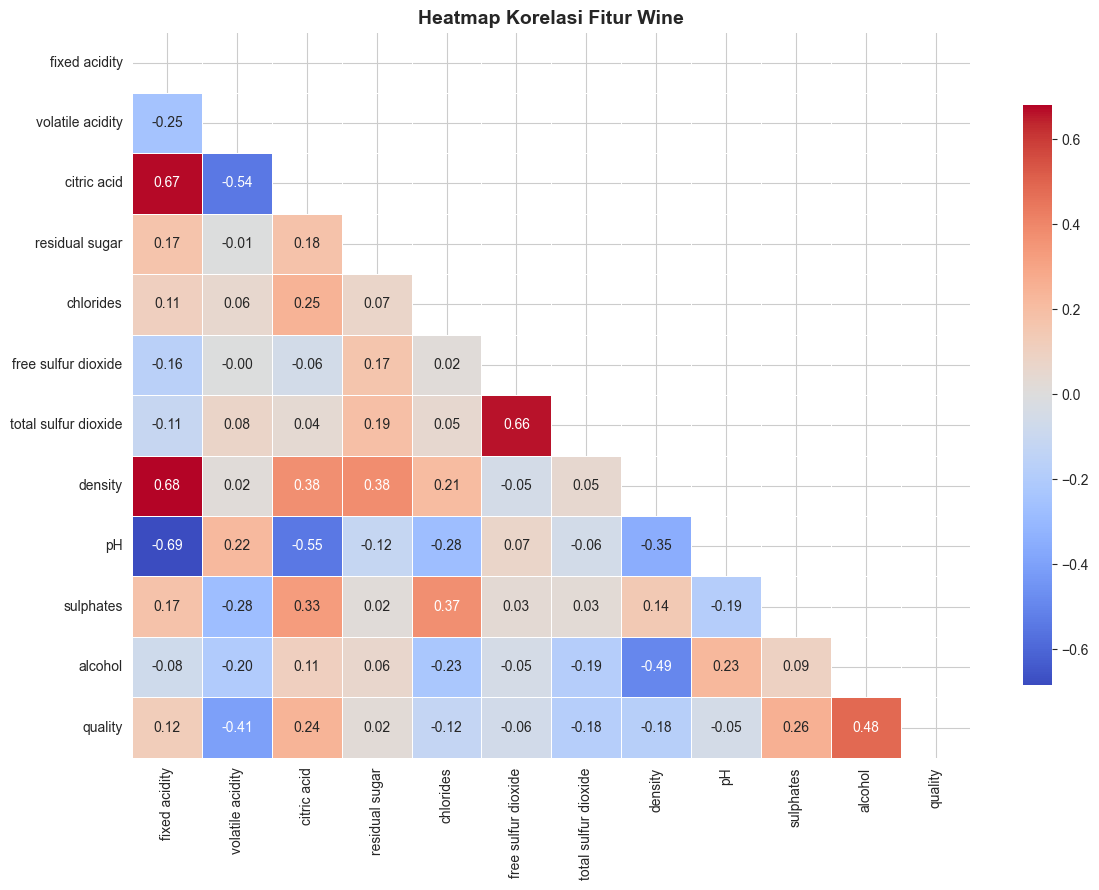

In [7]:
plt.figure(figsize=(12, 9))
corr = df.drop(columns=["Id"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Heatmap Korelasi Fitur Wine", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

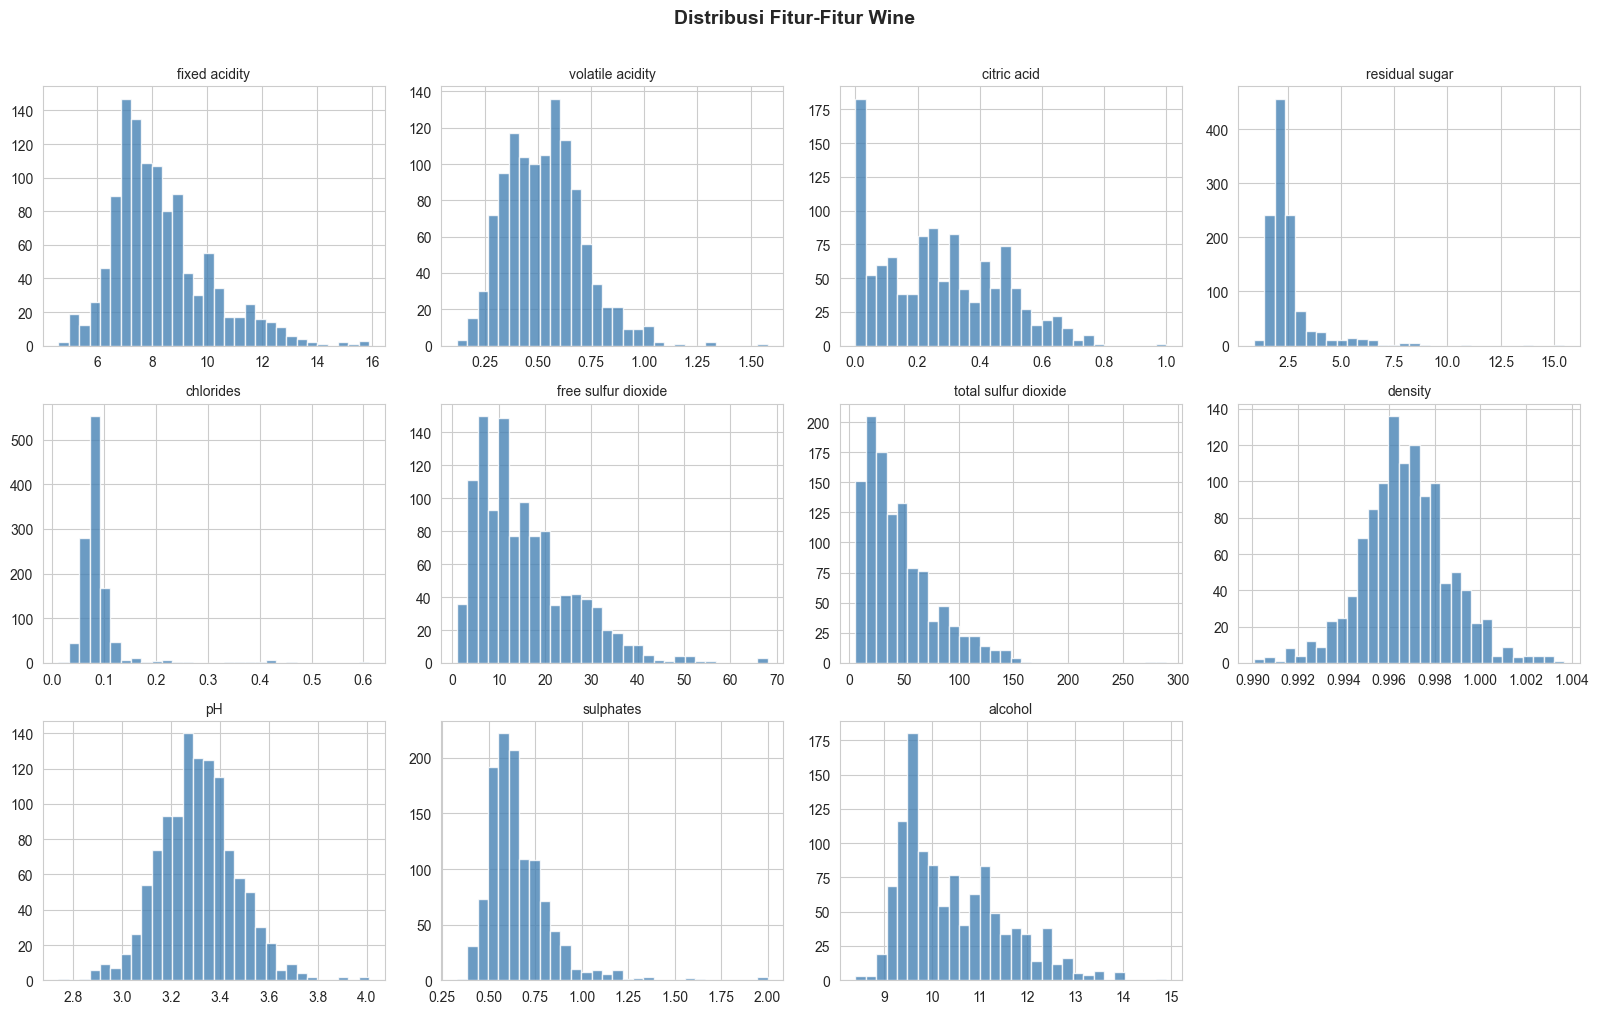

In [8]:
features = [c for c in df.columns if c not in ["quality", "Id"]]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("")
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distribusi Fitur-Fitur Wine", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. Preprocessing Data

In [9]:
X = df.drop(columns=["Id", "quality"])
y_true = df["quality"]

print(f"Fitur yang digunakan: {X.columns.tolist()}")
print(f"Jumlah fitur        : {X.shape[1]}")

Fitur yang digunakan: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Jumlah fitur        : 11


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("Statistik setelah StandardScaler:")
print(X_scaled_df.describe().round(4))

Statistik setelah StandardScaler:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count      1143.0000         1143.0000    1143.0000       1143.0000   
mean         -0.0000            0.0000       0.0000          0.0000   
std           1.0004            1.0004       1.0004          1.0004   
min          -2.1245           -2.2909      -1.3650         -1.2043   
25%          -0.6933           -0.7732      -0.9072         -0.4664   
50%          -0.2353           -0.0631      -0.0934         -0.2451   
75%           0.4516            0.6052       0.7713          0.0501   
max           4.3444            5.8403       3.7214          9.5681   

       chlorides  free sulfur dioxide  total sulfur dioxide    density  \
count  1143.0000            1143.0000             1143.0000  1143.0000   
mean      0.0000              -0.0000                0.0000     0.0000   
std       1.0004               1.0004                1.0004     1.0004   
min      -1.5860              

## 5. Menentukan Jumlah Cluster Optimal

### 5.1 Metode Elbow

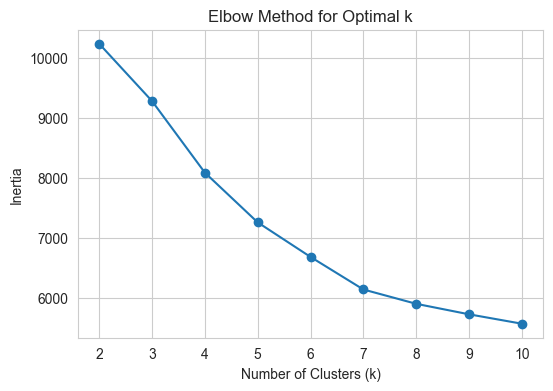

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(6, 4))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.title('Elbow Method for Optimal k')

plt.grid(True)

plt.show()

### 5.2 Silhouette Score

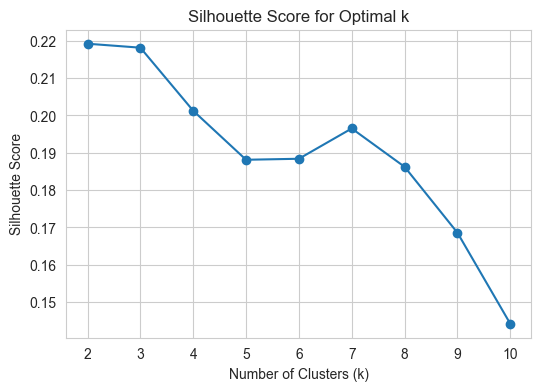

In [12]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

# Plot
plt.figure(figsize=(6, 4))

plt.plot(K, silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.title('Silhouette Score for Optimal k')

plt.grid(True)

plt.show()

## 6. Training Model K-Means

In [13]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans.fit(X_scaled)
df["Cluster"] = kmeans.labels_

print(f"Model K-Means berhasil dilatih!")
print(f"Inertia (WCSS)   : {kmeans.inertia_:.2f}")
print(f"Jumlah iterasi   : {kmeans.n_iter_}")
print(f"Distribusi cluster:")
print(df["Cluster"].value_counts().sort_index())

Model K-Means berhasil dilatih!
Inertia (WCSS)   : 9059.68
Jumlah iterasi   : 31
Distribusi cluster:
Cluster
0    523
1    271
2    349
Name: count, dtype: int64


## 7. Evaluasi Model

In [14]:
sil = silhouette_score(X_scaled, kmeans.labels_)
db  = davies_bouldin_score(X_scaled, kmeans.labels_)

print("       EVALUASI K-MEANS (K=3)")

print(f"  Silhouette Score     : {sil:.4f}  (mendekati 1 = baik)")
print(f"  Davies-Bouldin Score : {db:.4f}  (mendekati 0 = baik)")
print(f"  Inertia (WCSS)       : {kmeans.inertia_:.2f}")

       EVALUASI K-MEANS (K=3)
  Silhouette Score     : 0.1829  (mendekati 1 = baik)
  Davies-Bouldin Score : 1.7780  (mendekati 0 = baik)
  Inertia (WCSS)       : 9059.68


In [15]:
pivot = pd.crosstab(df["Cluster"], df["quality"])
print("Distribusi Kualitas Wine per Cluster:")
print(pivot)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).round(3)
print("Proporsi Kualitas per Cluster:")
print(pivot_pct)

Distribusi Kualitas Wine per Cluster:
quality  3   4    5    6   7   8
Cluster                         
0        4  22  216  230  46   5
1        0   6  175   79  10   1
2        2   5   92  153  87  10
Proporsi Kualitas per Cluster:
quality      3      4      5      6      7      8
Cluster                                          
0        0.008  0.042  0.413  0.440  0.088  0.010
1        0.000  0.022  0.646  0.292  0.037  0.004
2        0.006  0.014  0.264  0.438  0.249  0.029


In [16]:
cluster_means = df.groupby("Cluster")[X.columns.tolist()].mean().round(3)

# Label deskriptif berdasarkan rata-rata quality
quality_by_cluster = df.groupby("Cluster")["quality"].mean().sort_values()
label_map = {}
labels_name = ["Wine Rendah", "Wine Sedang", "Wine Tinggi"]
for i, idx in enumerate(quality_by_cluster.index):
    label_map[idx] = labels_name[i]

df["Cluster_Label"] = df["Cluster"].map(label_map)

print("Rata-rata Fitur per Cluster:")
print(cluster_means)

Rata-rata Fitur per Cluster:
         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0                7.190             0.606        0.123           2.191   
1                8.163             0.547        0.282           3.018   
2               10.107             0.407        0.476           2.666   

         chlorides  free sulfur dioxide  total sulfur dioxide  density     pH  \
Cluster                                                                         
0            0.078               13.390                34.400    0.996  3.403   
1            0.087               26.268                88.566    0.997  3.283   
2            0.101               10.679                30.052    0.998  3.195   

         sulphates  alcohol  
Cluster                      
0            0.611   10.532  
1            0.624    9.865  
2            0.754   10.755  


## 8. Visualisasi Hasil Clustering

### 8.1 Visualisasi PCA 2D

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variansi yang dijelaskan PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variansi yang dijelaskan PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variansi terjaga      : {sum(pca.explained_variance_ratio_)*100:.1f}%")

Variansi yang dijelaskan PC1: 28.7%
Variansi yang dijelaskan PC2: 17.1%
Total variansi terjaga      : 45.8%


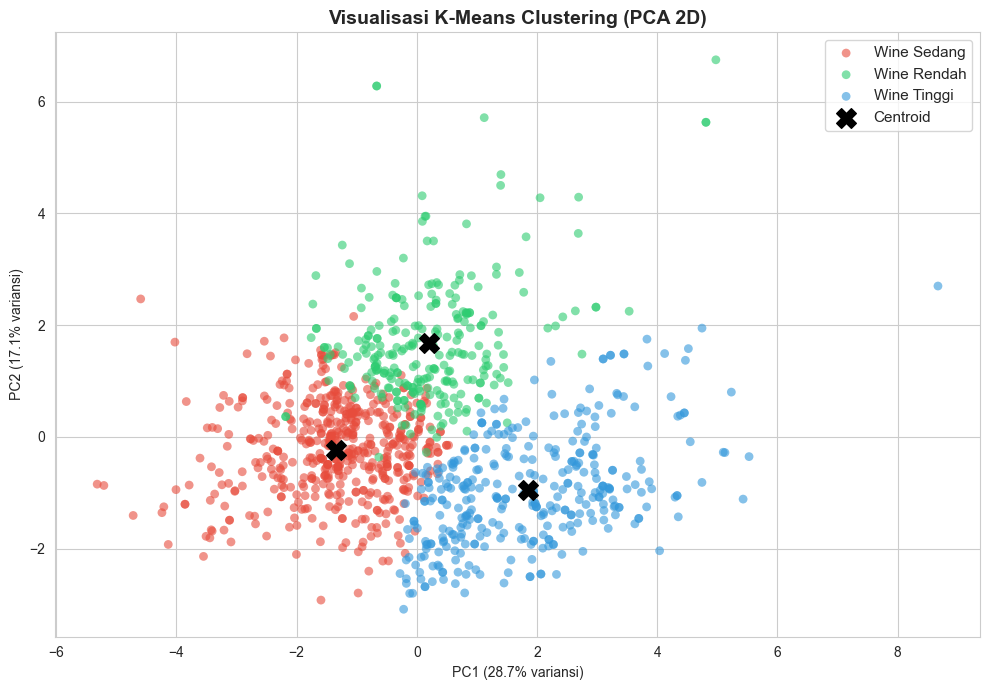

In [18]:
colors = ["#e74c3c", "#2ecc71", "#3498db"]
cluster_labels = [label_map[i] for i in range(optimal_k)]

plt.figure(figsize=(10, 7))
for i in range(optimal_k):
    mask = kmeans.labels_ == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=label_map[i], alpha=0.6, s=40, edgecolors="none")

# Plot centroid
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c="black", marker="X", s=200, zorder=5, label="Centroid")

plt.title("Visualisasi K-Means Clustering (PCA 2D)", fontsize=14, fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 8.2 Boxplot Fitur Utama per Cluster

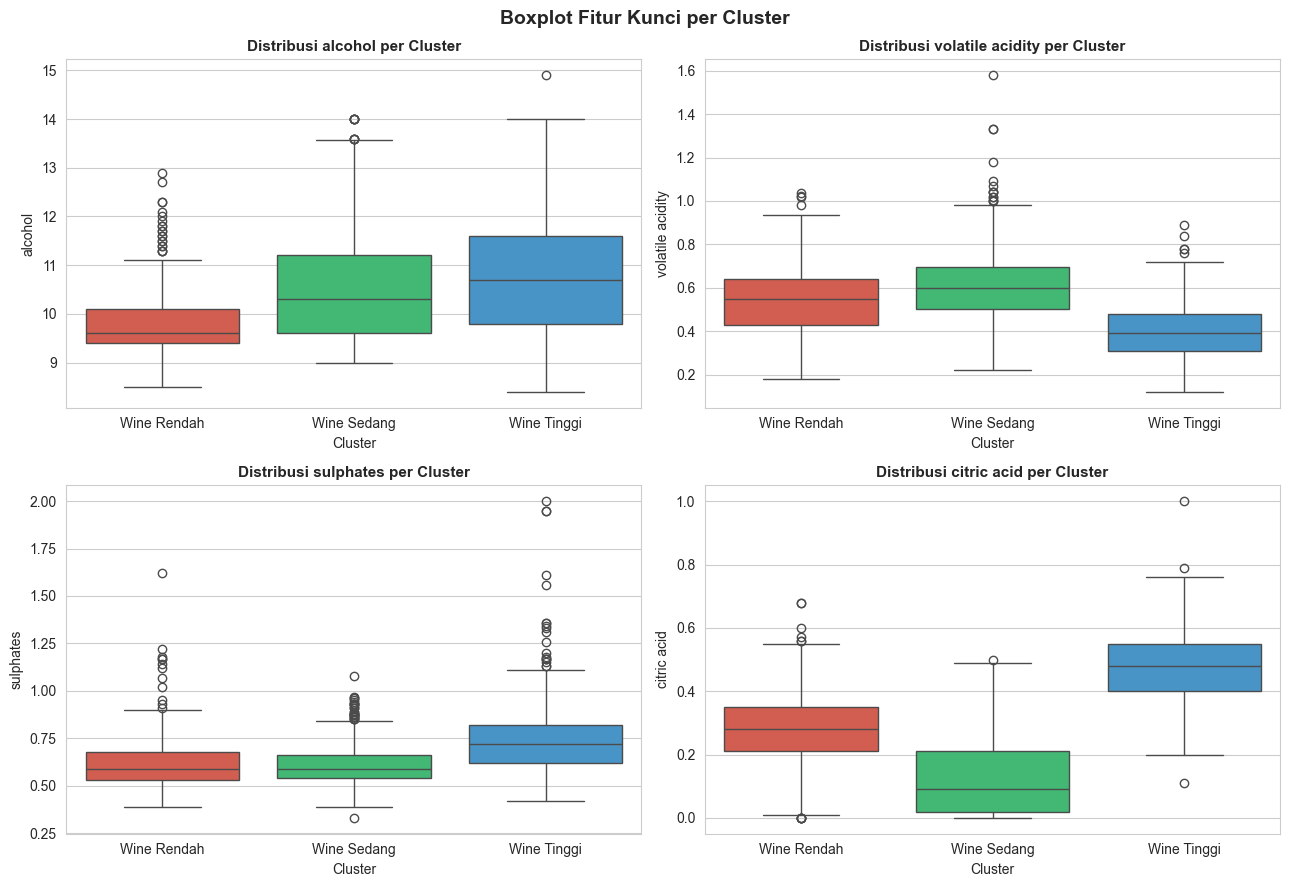

In [19]:
key_features = ["alcohol", "volatile acidity", "sulphates", "citric acid"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(x="Cluster_Label", y=feat, data=df,
                palette=["#e74c3c", "#2ecc71", "#3498db"],
                order=["Wine Rendah", "Wine Sedang", "Wine Tinggi"],
                ax=axes[i])
    axes[i].set_title(f"Distribusi {feat} per Cluster", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(feat)

plt.suptitle("Boxplot Fitur Kunci per Cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 9. Analisis Cluster

In [20]:
print("         PROFIL TIAP CLUSTER WINE")

for cluster_id in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == cluster_id]
    print(f"{label_map[cluster_id]} (Cluster {cluster_id})")
    print(f"   Jumlah sampel    : {len(subset)}")
    print(f"   Rata-rata kualitas: {subset["quality"].mean():.2f}")
    print(f"   Rata-rata alcohol : {subset["alcohol"].mean():.2f}%")
    print(f"   Volatile acidity  : {subset["volatile acidity"].mean():.3f}")
    print(f"   Sulphates         : {subset["sulphates"].mean():.3f}")
    print(f"   Citric acid       : {subset["citric acid"].mean():.3f}")

         PROFIL TIAP CLUSTER WINE
Wine Sedang (Cluster 0)
   Jumlah sampel    : 523
   Rata-rata kualitas: 5.59
   Rata-rata alcohol : 10.53%
   Volatile acidity  : 0.606
   Sulphates         : 0.611
   Citric acid       : 0.123
Wine Rendah (Cluster 1)
   Jumlah sampel    : 271
   Rata-rata kualitas: 5.35
   Rata-rata alcohol : 9.86%
   Volatile acidity  : 0.547
   Sulphates         : 0.624
   Citric acid       : 0.282
Wine Tinggi (Cluster 2)
   Jumlah sampel    : 349
   Rata-rata kualitas: 6.00
   Rata-rata alcohol : 10.76%
   Volatile acidity  : 0.407
   Sulphates         : 0.754
   Citric acid       : 0.476


## 10. Kesimpulan

Berdasarkan hasil analisis menggunakan algoritma K-Means Clustering pada dataset WineQT, proses clustering berhasil membagi data wine menjadi 3 cluster utama berdasarkan karakteristik kimia dari masing-masing wine. Sebelum dilakukan clustering, data terlebih dahulu melalui tahap preprocessing menggunakan StandardScaler agar seluruh fitur memiliki skala yang seimbang sehingga proses perhitungan jarak pada algoritma K-Means menjadi lebih optimal.

Secara keseluruhan, algoritma K-Means cukup efektif digunakan untuk melakukan segmentasi data wine dan menemukan pola tersembunyi dalam dataset tanpa menggunakan label kelas.